# pH Curve in a Buffer Solution

A buffer solution resists pH changes because it contains a weak acid and its conjugate base. The Henderson-Hasselbalch relationship estimates pH when the ratio between both forms is known {cite:p}`iupac_goldbook_henderson_hasselbalch`.

This example uses the acetic acid/acetate pair and calculates pH after adding strong acid or strong base:

$$
pH = pK_a + \log_{10}\left(\frac{n_{\mathrm{A^-}}}{n_{\mathrm{HA}}}\right)
$$

```{admonition} What to modify
:class: dropdown
Change `n_HA0`, `n_A0`, or the `additions` range. The $pK_a \pm 1$ band is usually the region where the buffer responds most gradually.
```


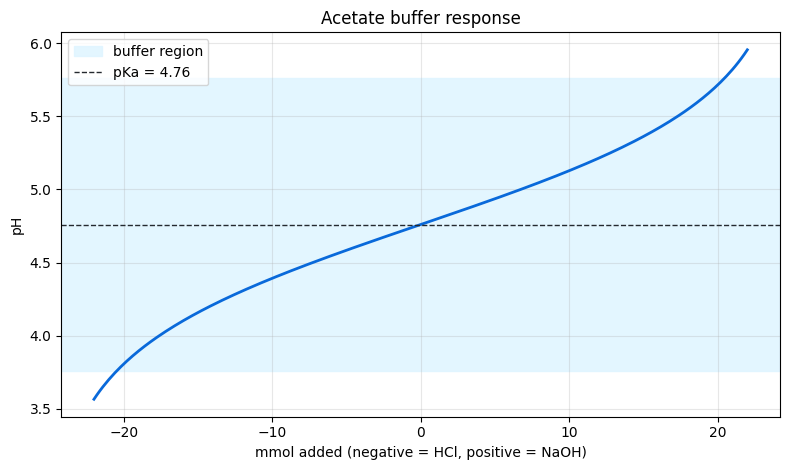

Initial pH = 4.76
pH after adding 10 mmol NaOH = 5.13
pH after adding 10 mmol HCl  = 4.39


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Editable parameters
pKa = 4.76
n_HA0 = 25.0  # mmol acetic acid
n_A0 = 25.0   # mmol acetate
additions = np.linspace(-22, 22, 220)  # negative: strong acid; positive: strong base

pH = []
for added in additions:
    if added >= 0:
        n_HA = n_HA0 - added
        n_A = n_A0 + added
    else:
        n_HA = n_HA0 - added
        n_A = n_A0 + added
    n_HA = max(n_HA, 1e-6)
    n_A = max(n_A, 1e-6)
    pH.append(pKa + np.log10(n_A / n_HA))
pH = np.array(pH)

plt.figure(figsize=(8, 4.8))
plt.plot(additions, pH, linewidth=2, color="#0969da")
plt.axhspan(pKa - 1, pKa + 1, color="#ddf4ff", alpha=0.8, label="buffer region")
plt.axhline(pKa, color="#24292f", linestyle="--", linewidth=1, label=f"pKa = {pKa}")
plt.xlabel("mmol added (negative = HCl, positive = NaOH)")
plt.ylabel("pH")
plt.title("Acetate buffer response")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Initial pH = {pKa + np.log10(n_A0/n_HA0):.2f}")
print(f"pH after adding 10 mmol NaOH = {pH[np.argmin(np.abs(additions - 10))]:.2f}")
print(f"pH after adding 10 mmol HCl  = {pH[np.argmin(np.abs(additions + 10))]:.2f}")


## Interpretation

The most stable region appears when acid and conjugate base amounts are comparable. Near the ends, one of the two forms is depleted and pH changes much more sharply.

```{admonition} Guided reading
:class: dropdown
Find the blue band. Inside that band, the same amount of added HCl or NaOH causes a smaller pH change than outside it. That is the practical idea behind buffer capacity.
```
